# Section 4 Optional:  Solving RBC via Sequence Space Jacobian Method

**Issues/Questions? Contact me via maragoneses@g.harvard.edu**

*Expands on Lecture Notes by Ludwig Straub and coauthors*


Here, we solve a simple RBC model much like what we'd do in Dynare for solving a representative agent model. Later, we will solve a het agent model. Essentially, the SHADE toolkit is to Python and heterogeneous agent models what Dynare is for Matlab for Representative Agent Models. 

The RBC Model is as follows

*Firms* supply output and demand inputs, capital and labor. Capital takes some time to build (i.e. is dynamic) and labor is hired in the spot market. Since we have perfect competition and CRS technology, firms make zero profits.

$
Y_{t}	= Y_{t}(Z_{t},K_{t-1},L_{t})=Z_{t}K_{t-1}^{\alpha}L_{t}^{1-\alpha}\quad\text{Good Supply}
\\
w_{t}	= w_{t}(Z_{t},K_{t-1},L_{t})=(1-\alpha)Z_{t}\left(\frac{K_{t-1}}{L_{t}}\right)^{\alpha},\quad\text{Labor Demand}
\\
r_{t+1}^{k}= r_{t+1}^{k}(Z_{t+1},K_{t},L_{t+1})= \alpha Z_{t+1}\left(\frac{K_{t}}{L_{t+1}}\right)^{\alpha-1}\quad\text{Asset/Capital Demand chosen at t}
\\
r_{t}^{k}=r_{t}^{k}(Z_{t},K_{t-1},L_{t})=\alpha Z_{t}\left(\frac{K_{t-1}}{L_{t}}\right)^{\alpha-1}\quad\text{Asset/Capital Demand chosen at t-1}
\\
Y_{t} - w_{t}L_{t} - r_{t-1}K_{t-1} = 0 
$

*Capital* accumulation and no-arbitrage
$
\\
 I_{t} = I_{t}(K_{t},K_{t-1}) =  K_{t} - (1-\delta)K_{t-1} , \quad\text{Investment Demand}
\\
1+ r_{t+1}^{k} = 1 + r_{t+1} + \delta
$

*Households* demand output for consumption, and supply labor and capital (via their asset savings)

All households are identical, and thus, we can aggregate individual budget constraints to get a rep household's budget constraint 
$
C_{t}+A_{t}=(1+r_{t})A_{t-1}+w_{t}L_{t}
$

$
w_{t}	= w_{t}(L_{t},C_{t})=\varphi L_{t}^{\nu}C_{t}^{\sigma},\quad\text{Labor Supply}
\\
C_{t}^{-\sigma}=\beta\left(1+r_{t+1}\right)C_{t+1}^{-\sigma}\quad\text{Asset/Capital Supply}
\\
C_{t}=C_{t}(r_{t+1},C_{t+1})
$

As will become clear below, given $L_{t}$ and $w_{t}$ from the firm side, static equilibrium consumption must also satisfy

$
C_{t}=C_{t}(w_{t},L_{t})= (w_{t}/L_{t}^{\nu})^{-\sigma}
$

*Market Clearing* must make sure that output produced by firms is consistent with consumption demand and intermediate investment demand to build new capital

$
Y_{t}	= Y_{t}(C_{t},I_{t-1}) = C_{t}+I_{t}\quad\text{Good Demand}
\\
Y_{t}=C_{t}+K_{t}-(1-\delta)K_{t-1}\quad\text{Good Demand}
$

$$
\textbf{H}_t(\textbf{U}, Z) \equiv 
\begin{pmatrix}
C_t^{-\sigma} - \beta (1 + r_{t+1}) C_{t+1}^{-\sigma}
\\
w_t - \varphi L_t^{\nu} C_t^{\sigma}
\\
K_t - (1 - \delta) K_{t-1} - I_t
\\
r_t + \delta -\alpha Z_t \left(\frac{K_{t-1}}{L_t} \right)^{\alpha-1}
\\
w_t - (1-\alpha) Z_t \left(\frac{K_{t-1}}{L_t} \right)^{\alpha}
\\
Y_t - Z_t K_{t-1}^\alpha L_t^{1-\alpha}
\\
Y_t - C_t - I_t
\end{pmatrix}
= \begin{pmatrix} 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0\end{pmatrix},
\qquad t = 0, 1, \dots 
\tag{1}
$$

As usual, labor market clearing is imposed implicitly and asset market clearing is omitted by Walras's law. Make sure you can derive it from the household budget constraint. 

## 0 Import packages
The first two are standard python packages, the rest contain code we wrote for this project.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import utils
from simple_block import simple
import jacobian as jac
import nonlinear

## 1 Steady state

The first step of solving a model is to compute its steady state. We achieve this in general by writing a function that takes in parameters and calibration targets and returns a dict(ionary) of steady state values. 

In this simple case, the steady state is fully analytical. We choose the discount rate $\beta$ to hit a given real interest rate $r$, the disutility of labor $\varphi$ to hit labor $L=1$, and normalize TFP $Z$ to get output $Y=1$. 

$$
\beta=\frac{1}{1+r},\quad r^{k}=r+\delta
\\
\frac{r^{k}}{\alpha}=Z\left(K\right)^{\alpha-1}=\left(K\right)^{-1}\implies K=\frac{\alpha}{r^{k}}
\\
Z=K^{-\alpha}=\left(\frac{r^{k}}{\alpha}\right)^{\alpha}, \implies Y=ZK^{\alpha}=\left(\frac{r^{k}}{\alpha}\right)^{\alpha}\left(\frac{\alpha}{r^{k}}\right)^{\alpha}=1
\\
I=\delta K
\\
C=1-\delta K
\\
w=(1-\alpha)Z\left(K\right)^{\alpha}
\\
\varphi=wC^{-\sigma}
$$

As a sanity check, we compute the error in Walras's law, residual of HH budget constraint, i.e. capital market clearing.
To see why, notice that in the steady state, for A = K and there are zero profits due to CRS competitive production, we must have
$$
C+A=(1+r)A+wL\implies C=r*K+w
$$

In [2]:
def rbc_ss(r=0.01, eis=1, frisch=1, delta=0.025, alpha=0.11):
    """Solve steady state of simple RBC model.
        
    Parameters
    ----------
    r      : scalar, real interest rate
    eis    : scalar, elasticity of intertemporal substitution (1/sigma)
    frisch : scalar, Frisch elasticity (1/nu)
    delta  : scalar, depreciation rate
    alpha  : scalar, capital share

    Returns
    -------
    ss : dict, steady state values
    """
    # solve for aggregates analytically
    rk = r + delta
    Z = (rk / alpha) ** alpha  # normalize so that Y=1
    K = (alpha * Z / rk) ** (1 / (1 - alpha))
    Y = Z * K ** alpha
    w = (1 - alpha) * Z * K ** alpha
    I = delta * K
    C = Y - I
    
    # preference params
    beta = 1 / (1 + r)
    vphi = w * C ** (-1 / eis)
    
    # check Walras's law
    walras = C - r * K - w
    assert np.abs(walras) < 1E-12

    # returns a dictionary of steady state values
    return {'beta': beta, 'eis': eis, 'frisch':frisch, 'vphi': vphi, 'delta': delta, 'alpha': alpha,
            'Z': Z, 'K': K, 'I': I, 'Y': Y, 'L': 1, 'C': C, 'w': w, 'r': r, 'walras': walras}

Let's run this function to get the steady state for the default parameters.

In [3]:
ss = rbc_ss()
print(ss)
# Note, as will be useful below, to reference a particular entry of the dictionary, 
# all we have to do is call it via it's string name. 

ss['Z']


{'beta': 0.9900990099009901, 'eis': 1, 'frisch': 1, 'vphi': 0.9658914728682173, 'delta': 0.025, 'alpha': 0.11, 'Z': 0.8816460975214567, 'K': 3.1428571428571432, 'I': 0.07857142857142858, 'Y': 1.0, 'L': 1, 'C': 0.9214285714285714, 'w': 0.8900000000000001, 'r': 0.01, 'walras': -2.220446049250313e-16}


0.8816460975214567

Being able to print steady state values will be useful below.

## 2 Model blocks

The second step of solving the model is to come up with a Directed Acyclic Graph (DAG) representation for it and specify its building blocks.

The 7 equations of the model can be organized as three simple blocks to form a Directed Acyclic Graph (DAG) in two unknowns $\{K, L\}$ and two targets, the euler equation and goods market clearing:

![Directed Acyclic Graph for RBC model](figures/rbc_dag.png) 


In our code, simple blocks are specified as regular Python functions  endowed with the decorator ``@simple``. In the body of the function, we directly implement the corresponding equilibrium conditions. The decorator turns the function into an instance of ``SimpleBlock``, a class that, among other things, knows how to handle time displacements such as `K(-1)` to denote 1-period lags and `r(+1)` to denote 1-period leads. In general, one can write (-s) and (+s) to denote s-period lags and leads. 

NOTE: Think of this step as the model definition you put into Dynare after setting up the key parameters of the model (and before defining the steady state).

We are taking as given sequences of exogenous $\{Z_{t}\}$ and endogenous unknowns $\{K_{t}, L_{t}\}$ which we treat as if they were known, and solve for them in equilibrium. 

As standard in equilibrium solvers, an equilibrium is a series of function $F_{k} = F_{k}(X,\Theta,Z)$ given equilibrium objects $X$, (fixed) parameters $\Theta$ and (variable parameters) "shocks" $Z$ such that we can define a system of non-linear equations to be "targetted" or "cleared" or "hit". Typically, this involves solving investment policy or value function and resource constraints that are defined implicitly. In estimation, these targets to clear will include parameters we want to calibrate the model to. 

Typically, such target functions take the form of a function that can be made close to 0 by adjusting $X$. In our case, 
$$X=(K,L), \forall t$$

$$
H(F_{k}(X,\Theta,Z)) = H_{LHS}(F_{k}(X,\Theta,Z)) - H_{RHS}(F_{k}(X,\Theta,Z)) \rightarrow 0
$$

From *firms*, we return $(w_{t},r_{t},Y_{t})$ as outputs from inputs $(Z_{t},K_{t-1},L_{t})$. Note that unlike in Keynesian models, we do not need to solve for profits. 

$$
w_{t}	= w_{t}(Z_{t},K_{t-1},L_{t})
\\
r_{t}   =r_{t}^{k}(Z_{t},K_{t-1},L_{t}) - \delta
\\
Y_{t}	= Y_{t}(Z_{t},K_{t-1},L_{t})
\\
D_{t}   = Y_{t} - w_{t}L_{t} - r_{t-1}K_{t-1} = 0 
$$

From *households*, we return  $(C_{t},I_{t})$  given $(w_{t})$, $(K_{t})_{t}$ and $(L_{t})$ from labor and capital demanded by firms for production.

$$
C_{t}=C_{t}(w_{t},L_{t})
\\
I_{t} = I_{t}(K_{t},K_{t-1})
$$

Finally, there given all these inputs, there are two equations, or targets, we need to clear: the goods market clearing equation and the euler investment equation
$$
F_{Goods MKT} = Y_t - C_t - I_t \rightarrow 0
\\
F_{Euler} = C_{t} - C_{t}(r_{t+1},C_{t+1}) \rightarrow 0 
$$

Note that both the LHS and RHS can be expressed as a function of sequences of $X$, $Z$, and parameters $\Theta$

$$
H_{Goods MKT} = Y_{t}(Z_{t},K_{t-1},L_{t}) - C_{t}(w_{t}(Z_{t},K_{t-1},L_{t}),L_{t}) - I_t(K_{t},K_{t-1})
\\
H_{Euler} = C_{t}(w_{t}(Z_{t},K_{t-1},L_{t}),L_{t}) - C_{t}(r_{t}^{k}(Z_{t},K_{t-1},L_{t}) - \delta,C_{t+1}(w_{t}(Z_{t},K_{t-1},L_{t}),L_{t}))
$$


In [4]:
@simple
def firm(K, L, Z, alpha, delta):
    r = alpha * Z * (K(-1) / L) ** (alpha-1) - delta
    w = (1 - alpha) * Z * (K(-1) / L) ** alpha
    Y = Z * K(-1) ** alpha * L ** (1 - alpha)
    return r, w, Y

@simple
def household(K, L, w, eis, frisch, vphi, delta):
    C = (w / vphi / L ** (1 / frisch)) ** eis
    I = K - (1 - delta) * K(-1)
    return C, I

@simple
def mkt_clearing(r, C, Y, I, K, L, w, eis, beta):
    goods_mkt = Y - C - I
    euler = C ** (-1 / eis) - beta * (1 + r(+1)) * C(+1) ** (-1 / eis)
    walras = C + K - (1 + r) * K(-1) - w * L  # we can the check dynamic version too
    return goods_mkt, euler, walras

Note that we imported the decorator from the module `simple_model.py`. If you're interested in the inner workings of the SimpleBlock class, check it out.

## 3 Linearized solution

Recall that in equilibrium
$H(X,Z;\Theta) = 0$

So that using the Implicit Function Theorem
$(dHdX)(dXdZ) = - (dHdZ)$
$ dX_{z}= -dH_{x}^{-1}dH_{z}$

Thus, all we need to figure out is, for a given sequence of shocks $dZ$ what is the sequence of responses, or the IRF $dX = G dZ$ where the GE matrix $G=-dH_{x}^{-1}dH_{z}$ with entries $G^{x,z}$


The linearized impulse responses of the model are fully characterized by the general equilibrium Jacobians $G$. These matrices map *any* sequence of shocks into an impulse response, e.g. $dC = G^{C,Z} dZ.$ Once we have them, we're pretty much done!

We can get all of these in a single call to the function `jacobian.get_G`. This function takes in the model blocks (in arbitrary order), the names of exogenous shocks, the names of unknown endogenous variables, the names of target equations, the truncation horizon, and the steady state dict.

In [5]:
G = jac.get_G(block_list = [firm, household, mkt_clearing],
              exogenous  = ['Z'],
              unknowns   = ['K', 'L'],
              targets    = ['euler', 'goods_mkt'],
              T          = 300,
              ss         = ss)

In [6]:
# Let's look at the dictionary inside of G
G


{'K': {'Z': array([[ 1.74501532e+00, -1.57897593e-01, -1.38568461e-01, ...,
          -1.36655808e-18, -8.94756496e-19, -4.41669277e-19],
         [ 1.54671216e+00,  1.60506118e+00, -2.80719165e-01, ...,
          -2.76844414e-18, -1.81264405e-18, -8.94756496e-19],
         [ 1.37094413e+00,  1.42266238e+00,  1.49619702e+00, ...,
          -4.22823385e-18, -2.76844414e-18, -1.36655808e-18],
         ...,
         [ 6.44815690e-16,  6.69603262e-16,  7.04622992e-16, ...,
           1.49619702e+00, -2.80719165e-01, -1.38568461e-01],
         [ 6.13306064e-16,  6.36209835e-16,  6.69427079e-16, ...,
           1.42266238e+00,  1.60506118e+00, -1.57897593e-01],
         [ 5.91567810e-16,  6.12967251e-16,  6.45533973e-16, ...,
           1.37094413e+00,  1.54671216e+00,  1.74501532e+00]])},
 'L': {'Z': array([[ 8.65698808e-01, -8.25485010e-02, -7.24432746e-02, ...,
          -7.14433442e-19, -4.67776651e-19, -2.30903689e-19],
         [-8.33739860e-02,  8.73242897e-01, -7.59279259e-02, ...,
 

In [7]:
# Any variable that 
type(G)
len(G) 
G['L'] 
# G[] Click inside of [] and press "tab" to see what's inside of the dictionary

# Intitially, one may think that there is a bug in the code, since any variable spits out Z while G['Z'] spits out KeyError
# This is because G is defined as dX = G dZ, where dZ  IS A T-sized vector. 

# What we want is to access how any unknown variable changes with Z G['L']['Z']

G['K']['Z']

array([[ 1.74501532e+00, -1.57897593e-01, -1.38568461e-01, ...,
        -1.36655808e-18, -8.94756496e-19, -4.41669277e-19],
       [ 1.54671216e+00,  1.60506118e+00, -2.80719165e-01, ...,
        -2.76844414e-18, -1.81264405e-18, -8.94756496e-19],
       [ 1.37094413e+00,  1.42266238e+00,  1.49619702e+00, ...,
        -4.22823385e-18, -2.76844414e-18, -1.36655808e-18],
       ...,
       [ 6.44815690e-16,  6.69603262e-16,  7.04622992e-16, ...,
         1.49619702e+00, -2.80719165e-01, -1.38568461e-01],
       [ 6.13306064e-16,  6.36209835e-16,  6.69427079e-16, ...,
         1.42266238e+00,  1.60506118e+00, -1.57897593e-01],
       [ 5.91567810e-16,  6.12967251e-16,  6.45533973e-16, ...,
         1.37094413e+00,  1.54671216e+00,  1.74501532e+00]])

To see the $G$ matrices in action, let's construct two sequences of TFP shocks. 

First, a usual autoregressive shock that hits in period 0 (when the economy is assumed to be in steady state). 

Second, a news shock that, as agents learn in period 0, will hit TFP in period 10 and then decay at a constant rate. Note that such a news shock would be very costly to formulate recursively.

We store the two sequences as columns of a matrix $dZ$. Let the shock on impact be 1% of steady state productivity, and the  quarterly autocorrelation be 0.8. 

Note that 

$ dZ(t) = (\Delta)Z \rho^{t-1}$

In [8]:
# Define IRF horizon, size of the shock, autocorrelation, period when news shock hits
T, impact, rho, news, news2 = 300, 0.01, 0.8, 10, 5
# Unlike Matlab, definitions do not print output
# Simply type to print
news

10

In [9]:
dZ = np.empty((T, 3)) 
# NP return a new array (a matrix) of given shape (T,2) 
# The first column [:,0] will be the first shock -- note that Python, unlike Matlab, indexes the first entry as 0
dZ

array([[0.00000000e+000, 6.94137441e-310, 0.00000000e+000],
       [2.17841280e-314, 6.94137441e-310, 0.00000000e+000],
       [6.94137441e-310, 7.75683064e-322, 2.17841271e-314],
       [6.94137441e-310, 0.00000000e+000, 6.94137441e-310],
       [5.53353523e-322, 2.17841271e-314, 6.94137441e-310],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000

In [10]:
vT = np.arange(T)
dZ[:, 0] = impact * ss['Z'] * (rho**vT)

# Define 

vT


array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [11]:
# The first n periods are zero
np.zeros(news)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [12]:
# The periods starting from n (news:end) = (:-news) 
dZ[:-news, 0]
dZ[:-news, 0].shape

(290,)

In [13]:
dZ.shape
# x = T periods
# y = 2 shocks

(300, 3)

In [14]:
dZ[:, 1] = np.concatenate((np.zeros(news), dZ[:-news, 0])) 
dZ[:, 2] = np.concatenate((np.zeros(news2), dZ[:-news2, 0])) 
dZ

array([[8.81646098e-03, 0.00000000e+00, 0.00000000e+00],
       [7.05316878e-03, 0.00000000e+00, 0.00000000e+00],
       [5.64253502e-03, 0.00000000e+00, 0.00000000e+00],
       [4.51402802e-03, 0.00000000e+00, 0.00000000e+00],
       [3.61122242e-03, 0.00000000e+00, 0.00000000e+00],
       [2.88897793e-03, 0.00000000e+00, 8.81646098e-03],
       [2.31118235e-03, 0.00000000e+00, 7.05316878e-03],
       [1.84894588e-03, 0.00000000e+00, 5.64253502e-03],
       [1.47915670e-03, 0.00000000e+00, 4.51402802e-03],
       [1.18332536e-03, 0.00000000e+00, 3.61122242e-03],
       [9.46660289e-04, 8.81646098e-03, 2.88897793e-03],
       [7.57328231e-04, 7.05316878e-03, 2.31118235e-03],
       [6.05862585e-04, 5.64253502e-03, 1.84894588e-03],
       [4.84690068e-04, 4.51402802e-03, 1.47915670e-03],
       [3.87752054e-04, 3.61122242e-03, 1.18332536e-03],
       [3.10201643e-04, 2.88897793e-03, 9.46660289e-04],
       [2.48161315e-04, 2.31118235e-03, 7.57328231e-04],
       [1.98529052e-04, 1.84894

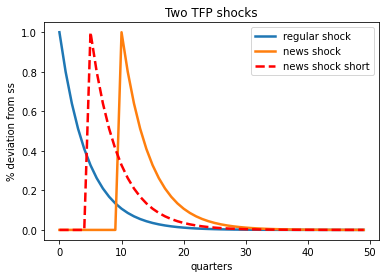

In [15]:
# Plot first Tend periods the two shocks jointly 
Tend = 50

# Unlike Matlab, where you have to spell out y(x,y) leaving out the x's in Python simply plots y axis against count

plt.plot(100*dZ[:Tend, 0]/ss['Z'], label='regular shock', linewidth=2.5)
plt.plot(100*dZ[:Tend, 1]/ss['Z'], label='news shock', linewidth=2.5)
plt.plot(100*dZ[:Tend, 2]/ss['Z'], 'r--', label='news shock short', linewidth=2.5)

plt.title(r'Two TFP shocks')
plt.ylabel(r'% deviation from ss')
plt.xlabel(r'quarters')
plt.legend()
plt.show()

Just apply the $G$ matrix to map these into impulses responses for, say, consumption. We multiply by 100 and divide by $C_{ss}$ just to get the answer in units of % deviations from steady state.

To apply a matrix, we use the `@` matrix operator in Python

In [16]:
A = np.matrix('3 1; 8 2')
B = np.matrix('6 1; 7 9')
C = np.matrix('6 1')
C = C.T

A, B, C

(matrix([[3, 1],
         [8, 2]]),
 matrix([[6, 1],
         [7, 9]]),
 matrix([[6],
         [1]]))

In [17]:
Out1 = A @ B
Out2 = A @ C

Out1, Out2, Out1.shape, Out2.shape

(matrix([[25, 12],
         [62, 26]]),
 matrix([[19],
         [50]]),
 (2, 2),
 (2, 1))

In [18]:
n1 = dZ.shape
n2 = G['C']['Z'].shape

n2, n1

((300, 300), (300, 3))

In [19]:
dC = 100 * G['C']['Z'] @ dZ / ss['C']
G['C']['Z']
# Note dZ has TxS where S are the different shocks to Z and 
dZ.shape
# And G(C,Z) = dXdZ(C,:,:) = is TxT since G is UxTxT 
G['C']['Z'].shape
# This has the interpretation of how much a change  dZ(t) affects any dX(k) either prior or future
dC.shape
# Thus, dC has T,S, or the IRF for each of the S shocks

(300, 3)

Now plot the result.

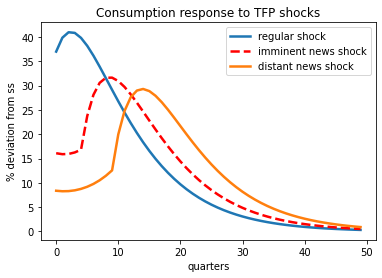

In [20]:
plt.plot(100*dC[:Tend, 0], label='regular shock', linewidth=2.5)
plt.plot(100*dC[:Tend, 2], 'r--', label='imminent news shock', linewidth=2.5)
plt.plot(100*dC[:Tend, 1], label='distant news shock', linewidth=2.5)

plt.legend()
plt.title(r'Consumption response to TFP shocks')
plt.ylabel(r'% deviation from ss')
plt.xlabel(r'quarters')
plt.show()

For those of you familiar with Dynare, these impulse responses are identical to what you could obtain by running the perfect foresight solver `simul` with the `linear_approximation` option.

## 4 Nonlinear solution

To obtain nonlinear impulse responses that capture the different scale and sign effects of shocks, we use `nonlinear.td_solve`. Similarly to `get_G` above, it takes in the steady state dict, the model blocks (in arbitrary order), the names of unknown endogenous variables and the names of target equations.

However, the names of the exogenous variables would not be sufficient, since we're calculating the nonlinear response to a specific shock. Instead, `td_solve` takes the actual *sequences* for any exogenous variables that are shocked.

So for the first news shock above, we can just call: 

In [21]:
dZ_news = ss['Z']+dZ[:, 1]
dZ_news.shape

(300,)

In [22]:
td_nonlin = nonlinear.td_solve(ss         = ss, 
                               block_list = [firm, household, mkt_clearing],
                               unknowns   = ['K', 'L'],
                               targets    = ['goods_mkt', 'euler'],
                               Z          = dZ_news)

On iteration 0
   max error for goods_mkt is 7.86E-04
   max error for euler is 1.04E-02
On iteration 1
   max error for goods_mkt is 6.75E-05
   max error for euler is 6.68E-05
On iteration 2
   max error for goods_mkt is 1.27E-07
   max error for euler is 3.85E-07
On iteration 3
   max error for goods_mkt is 1.47E-09
   max error for euler is 3.60E-09


In [23]:
# td_nonlin is a dictionary with entries being the Tx1 IRFs to the shocks supplied above
td_nonlin['C'].shape
td_nonlin

{'Z': array([0.8816461 , 0.8816461 , 0.8816461 , 0.8816461 , 0.8816461 ,
        0.8816461 , 0.8816461 , 0.8816461 , 0.8816461 , 0.8816461 ,
        0.89046256, 0.88869927, 0.88728863, 0.88616013, 0.88525732,
        0.88453508, 0.88395728, 0.88349504, 0.88312525, 0.88282942,
        0.88259276, 0.88240343, 0.88225196, 0.88213079, 0.88203385,
        0.8819563 , 0.88189426, 0.88184463, 0.88180492, 0.88177316,
        0.88174774, 0.88172742, 0.88171115, 0.88169814, 0.88168773,
        0.88167941, 0.88167274, 0.88166741, 0.88166315, 0.88165974,
        0.88165701, 0.88165483, 0.88165308, 0.88165169, 0.88165057,
        0.88164967, 0.88164896, 0.88164839, 0.88164793, 0.88164756,
        0.88164727, 0.88164704, 0.88164685, 0.8816467 , 0.88164658,
        0.88164648, 0.8816464 , 0.88164634, 0.88164629, 0.88164625,
        0.88164622, 0.8816462 , 0.88164618, 0.88164616, 0.88164615,
        0.88164614, 0.88164613, 0.88164612, 0.88164612, 0.88164611,
        0.88164611, 0.88164611, 0.88164611,

As we can see, the linearized solution is very accurate in this case.

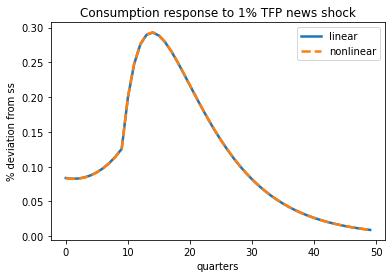

In [24]:
dC_nonlin = 100 * (td_nonlin['C']/ss['C'] - 1)

# Note that while the elemements of G were already in log-deviations, here we need to substract by 1.

plt.plot(dC[:50, 1], label='linear', linewidth=2.5)
plt.plot(dC_nonlin[:50], label='nonlinear',  linestyle='--', linewidth=2.5)
plt.title(r'Consumption response to 1% TFP news shock')
plt.ylabel(r'% deviation from ss')
plt.xlabel(r'quarters')
plt.legend()
plt.show()

For those of you familiar with Dynare, these impulse responses are identical to what you could obtain by running the perfect foresight solver `simul`.

## Review of programs used 

Define an internal function `rbc_ss` returning a dictionary with all steady state variables. 

Decorator of the SimpleBlock class (`simple_model.py`) defines all the model blocks taking model inputs - unknown endogenous variables and known exogenous shocks $(X,Z)$ - and returns model target equations $H(X,Z)$ to be linearized.

Function `jacobian.get_G`takes model blocks (in arbitrary order), the names of exogenous shocks, the names of unknown endogenous variables, the names of target equations, the truncation horizon, and the steady state dict.

##  Python 

Vector gen `vT = np.arange(T)` = `[0:T-1]` 
Matrix gen `mZ = np.empty((T, 2))` 
`np.zeros(news)`
`mX.shape`
`dZ[:, 1] = np.concatenate((np.zeros(news), dZ[:-news, 0]))`

`@` is a very useful matrix multiplication operator that we will use throughout the course. 
You can read more in 
https://numpy.org/devdocs/user/numpy-for-matlab-users.html
